### 24RB1075 小嶋将太郎

### 課題1

In [18]:
import numpy as np
import matplotlib.pyplot as plt

In [19]:
s = np.random.rand(100, 1) * 2 * np.pi
Z = np.hstack([4*np.cos(s), 3*np.sin(s)])
P = np.random.randn(2,5)
X = Z @ P + np.random.randn(100, 5)
X

array([[-2.33895702,  0.87799343,  1.82232309,  3.91183983, -0.26417328],
       [ 4.47100143, -3.86178849,  2.25253421, -0.59955928,  0.85607716],
       [ 6.18197824,  2.75402429, -2.39780125, -3.48026171,  1.55807311],
       [-2.66769028,  4.31854477, -3.59293785, -1.40360778, -1.1234577 ],
       [-5.27139616, -0.24629544,  1.61976316,  3.58331218, -0.3173446 ],
       [-2.94546065,  4.00318246, -3.13691276, -0.03745511,  0.64717308],
       [ 3.07909719, -4.27562514,  4.11307099,  0.9165413 , -0.53391515],
       [ 3.57119568, -1.52481388,  0.42763026, -3.61534117,  0.11376926],
       [-0.07269618, -2.17705891,  3.1290673 ,  1.92397338,  2.21849806],
       [ 4.36110285, -3.94212352,  2.78218322,  0.75401695,  0.72510935],
       [ 2.34648508, -2.90652986,  3.12555116, -1.79942284,  0.47899663],
       [-5.92472771, -1.13570554,  2.06342737,  4.28214566, -2.40612165],
       [-1.20210827,  4.22570562, -3.46304723,  0.06255071, -1.10857638],
       [ 0.2729204 ,  3.78559459, -2.5

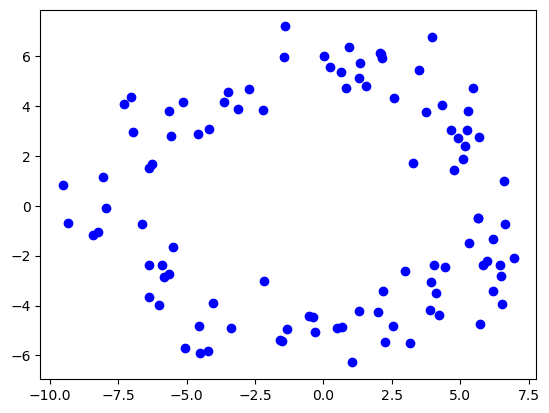

In [31]:
# データを中心化
X_centered = X - X.mean(axis=0)

# 共分散行列を計算
M = (X_centered.T @ X_centered) / X_centered.shape[0]

# 固有値と固有ベクトルを計算
eigvals, eigvecs = np.linalg.eigh(M)

# 固有値の大きい順に並べた
idx = np.argsort(eigvals)[::-1]
# 上位2固有ベクトルを選択
W = eigvecs[:, idx[:2]]
# データを2次元に射影
X_2d = X_centered @ W
# 2D散布図をプロット
plt.scatter(X_2d[:, 0], X_2d[:, 1],color = 'blue')
plt.show()


### 課題2

<function matplotlib.pyplot.show(close=None, block=None)>

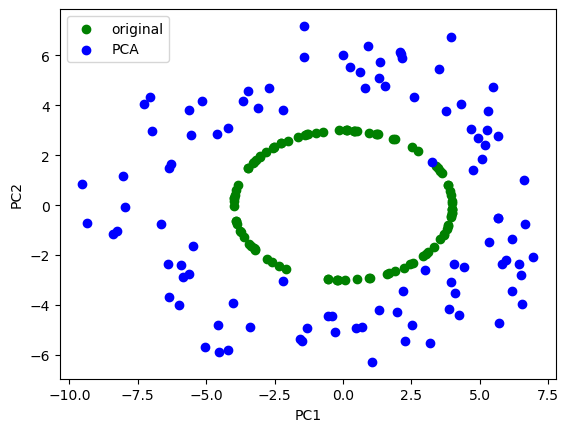

In [ ]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

Xpca = PCA(n_components=2).fit_transform(X)
plt.scatter(Z[:, 0], Z[:, 1], label='original',color = 'green')
plt.scatter(Xpca[:, 0], Xpca[:, 1], label='PCA',color = 'blue')
plt.legend()
plt.show

### 課題3

寄与率: [0.92461872 0.05306648]
累積寄与率: 0.977685206318798


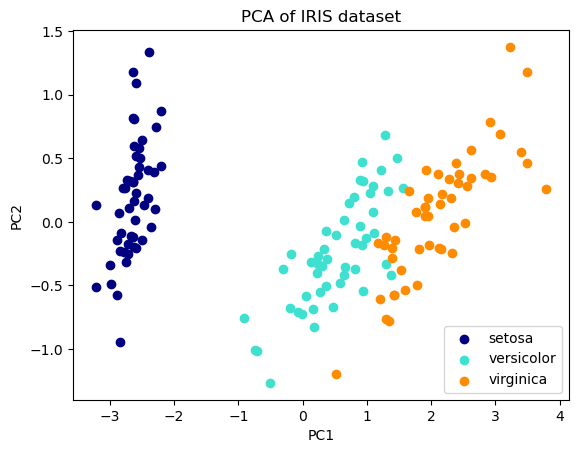

In [24]:
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
target_names = iris.target_names

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_iris)

explained = pca.explained_variance_ratio_
print("寄与率:", explained)
print("累積寄与率:", explained.sum())

colors = ['navy', 'turquoise', 'darkorange']
for i, color in enumerate(colors):
    plt.scatter(X_pca[y_iris == i, 0], X_pca[y_iris == i, 1], color=color, label=target_names[i])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("PCA of IRIS dataset")
plt.show()

### 考察

実際のプロセスに沿って自作でPCAを実装し、固有値分解によってデータを低次元空間に射影できることを確認した。

sklearnのPCAと比較したところ、結果が一致しており、自作のPCAが正しく実装できていることが分かった。

IrisデータセットにPCAを適用した結果、第1、第2主成分の寄与率はそれぞれ約0.92と約0.05、累積寄与率は約0.977となった。これは上位2固有ベクトルにより、元の4次元データの分散の大部分を説明していることが確認できる。